# Universidad del Valle de Guatemala
## Security Data Science
## Implementacion Parte 2

**Nombre:** Gabriel A. Paz Gonzalez  
**Carnet:** 221087

En la primera implementacion trabaje principalmente con senales basadas en URL usando PhiUSIIL. El feedback recibido fue correcto: para el problema investigado no basta con modelar solo la URL, porque el phishing moderno tambien depende del texto que acompana el enlace en correos, mensajes o paginas de aterrizaje. En esta segunda parte corrijo esa limitacion usando un dataset textual de correos y comparo modelos `URL-only`, `texto-only` y `URL + texto`.

## 1. Objetivo de esta implementacion

El objetivo de esta parte es implementar y evaluar modelos de clasificacion para detectar correos sospechosos/phishing a partir de dos grupos de senales:

- **Caracteristicas de URL:** longitud, uso de HTTPS, cantidad de digitos, estructura del host y tokens sospechosos extraidos de enlaces presentes en el correo.
- **Caracteristicas de texto:** representacion TF-IDF del asunto y cuerpo del correo.

Con esto se responde directamente al punto pendiente de la Parte 1: ahora la decision del modelo no depende solo de la URL, sino tambien del contenido textual que intenta persuadir al usuario.

In [1]:
from pathlib import Path
import math
import re
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
TEXT_DATA_PATH = DATA_DIR / "CEAS_08.csv"
TEXT_DATA_URL = "https://raw.githubusercontent.com/rokibulroni/Phishing-Email-Dataset/main/CEAS_08.csv"

print("Proyecto:", PROJECT_ROOT)
print("Dataset textual:", TEXT_DATA_PATH)

Proyecto: c:\Gabriel\UVG\9 SEMESTRE\SECURITY DATA SCIENCE\PROYECTO
Dataset textual: c:\Gabriel\UVG\9 SEMESTRE\SECURITY DATA SCIENCE\PROYECTO\data\CEAS_08.csv


## 2. Dataset complementario de textos

Para complementar PhiUSIIL se utiliza **CEAS_08.csv** del repositorio publico `rokibulroni/Phishing-Email-Dataset`. Este archivo contiene correos con `subject`, `body`, `label` y una marca de presencia de URLs. La etiqueta se interpreta asi:

- `0`: correo legitimo / benigno.
- `1`: correo sospechoso, spam o phishing.

La ventaja para esta fase es que el texto y las URLs aparecen en la misma fila. Eso permite comparar si el modelo mejora al combinar ambas fuentes de informacion.

In [2]:
if not TEXT_DATA_PATH.exists():
    TEXT_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    pd.read_csv(TEXT_DATA_URL).to_csv(TEXT_DATA_PATH, index=False)

emails_raw = pd.read_csv(TEXT_DATA_PATH, encoding="latin1")
print("Filas y columnas:", emails_raw.shape)
emails_raw.head()

Filas y columnas: (39154, 7)


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimension will soon be over!\nBecome a lover no woman will be able to resist!\nhttp://whitedone.c...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these techniques http://www.brightmade.com\n\n\n,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet.psi.br>,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,">+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug 1, 200...",1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/trunk: lib/Mail/SpamAssassin/PerMsgStatus.pm lib/Mail/SpamAssassin/Util/RegistrarBoundaries.p...,Would anyone object to removing .so from this list? The .so TLD is \nbasically dead and we've found that lots of bogus domains like li...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7iwfna.blu.livefilestore.com/y1pXdX3kwzhBa8xhXv8tdHbjHn7Tj4VT91YQg5lB5-_Hs9yuDwmU5wOteqBO-K...,1,1


In [3]:
summary = pd.DataFrame({
    "valor": [
        len(emails_raw),
        emails_raw.shape[1],
        int(emails_raw["subject"].isna().sum()),
        int(emails_raw["body"].isna().sum()),
        int(emails_raw.duplicated(subset=["subject", "body"]).sum()),
    ]
}, index=["filas", "columnas", "subject_nulos", "body_nulos", "duplicados_subject_body"])
summary

,valor
filas,39154
columnas,7
subject_nulos,28
body_nulos,0
duplicados_subject_body,0


In [4]:
class_distribution = (
    emails_raw["label"]
    .map({0: "legitimate", 1: "suspicious/phishing"})
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
class_distribution["pct"] = class_distribution["count"] / len(emails_raw)
class_distribution

,class,count,pct
0,suspicious/phishing,21842,0.557848
1,legitimate,17312,0.442152


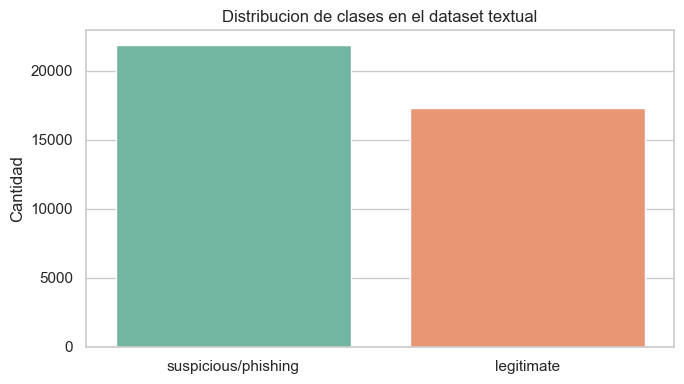

In [5]:
plt.figure(figsize=(7, 4))
sns.barplot(data=class_distribution, x="class", y="count", hue="class", legend=False, palette="Set2")
plt.title("Distribucion de clases en el dataset textual")
plt.xlabel("")
plt.ylabel("Cantidad")
plt.tight_layout()

La distribucion de clases no esta perfectamente balanceada, pero ambas clases tienen suficientes ejemplos para entrenar y evaluar modelos. Por eso en los modelos uso `class_weight="balanced"`, para que el clasificador no favorezca demasiado la clase mayoritaria.

## 3. Limpieza e ingenieria de caracteristicas

Aqui preparo dos vistas del mismo correo:

- `email_text`: union del asunto y cuerpo del correo para extraer senales linguisticas con TF-IDF.
- Caracteristicas numericas de URL extraidas con expresiones regulares desde el cuerpo del correo.

Si un correo no tiene URL visible, sus caracteristicas de URL quedan en cero. Esto tambien es una senal util: hay mensajes sospechosos sin URL directa o con enlaces ocultos/adjuntos.

In [6]:
URL_PATTERN = re.compile(r'https?://[^\s<>"\']+|www\.[^\s<>"\']+', flags=re.IGNORECASE)
SUSPICIOUS_TOKENS = [
    "login", "verify", "update", "account", "secure", "bank", "wallet", "password",
    "confirm", "signin", "support", "billing", "free", "gift", "urgent", "click"
]

def normalize_text(value):
    if pd.isna(value):
        return ""
    text = str(value)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_first_url(text):
    text = normalize_text(text)
    match = URL_PATTERN.search(text)
    if not match:
        return ""
    url = match.group(0).rstrip(".,);]")
    if url.lower().startswith("www."):
        url = "http://" + url
    return url

def shannon_entropy(text):
    if not text:
        return 0.0
    counts = pd.Series(list(text)).value_counts(normalize=True)
    return float(-(counts * np.log2(counts)).sum())

def url_features(url):
    if not url:
        return {
            "has_url": 0,
            "url_length": 0,
            "url_entropy": 0.0,
            "url_is_https": 0,
            "url_num_dots": 0,
            "url_num_digits": 0,
            "url_num_special": 0,
            "host_length": 0,
            "path_length": 0,
            "query_length": 0,
            "suspicious_token_hits": 0,
        }
    lower_url = url.lower()
    try:
        parsed = urlparse(url)
        host = parsed.netloc.lower()
        path = parsed.path or ""
        query = parsed.query or ""
        is_https = int(parsed.scheme.lower() == "https")
    except ValueError:
        host = ""
        path = ""
        query = ""
        is_https = int(lower_url.startswith("https://"))
    return {
        "has_url": 1,
        "url_length": len(url),
        "url_entropy": shannon_entropy(url),
        "url_is_https": is_https,
        "url_num_dots": url.count("."),
        "url_num_digits": sum(ch.isdigit() for ch in url),
        "url_num_special": len(re.findall(r"[^A-Za-z0-9]", url)),
        "host_length": len(host),
        "path_length": len(path),
        "query_length": len(query),
        "suspicious_token_hits": sum(token in lower_url for token in SUSPICIOUS_TOKENS),
    }

emails = emails_raw[["subject", "body", "label", "urls"]].copy()
emails["subject_clean"] = emails["subject"].map(normalize_text)
emails["body_clean"] = emails["body"].map(normalize_text)
emails["email_text"] = (emails["subject_clean"] + " " + emails["body_clean"]).str.strip()
emails["first_url"] = emails["body_clean"].map(extract_first_url)

url_feature_df = pd.DataFrame(emails["first_url"].map(url_features).tolist(), index=emails.index)
emails = pd.concat([emails, url_feature_df], axis=1)
emails["label_name"] = emails["label"].map({0: "legitimate", 1: "suspicious/phishing"})

emails = emails.drop_duplicates(subset=["email_text"]).reset_index(drop=True)
print("Dataset final:", emails.shape)
emails[["subject_clean", "first_url", "label", "label_name", "has_url", "url_length", "suspicious_token_hits"]].head()

Dataset final: (38963, 20)


,subject_clean,first_url,label,label_name,has_url,url_length,suspicious_token_hits
0,Never agree to be a loser,http://whitedone.com/,1,suspicious/phishing,1,21,0
1,Befriend Jenna Jameson,http://www.brightmade.com,1,suspicious/phishing,1,25,0
2,CNN.com Daily Top 10,http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/07/31/moos.montauk.monster.cnn,1,suspicious/phishing,1,100,0
3,Re: svn commit: r619753 - in /spamassassin/trunk: lib/Mail/SpamAssassin/PerMsgStatus.pm lib/Mail/SpamAssassin/Util/RegistrarBoundaries.p...,http://en.wikipedia.org/wiki/.so_%28domain_name%29,0,legitimate,1,50,0
4,SpecialPricesPharmMoreinfo,http://7iwfna.blu.livefilestore.com/y1pXdX3kwzhBa8xhXv8tdHbjHn7Tj4VT91YQg5lB5-_Hs9yuDwmU5wOteqBO-KnULiisB2QJJIug_bNfnrNH0YoSw/index.html,1,suspicious/phishing,1,136,0


In [7]:
url_feature_cols = [
    "has_url", "url_length", "url_entropy", "url_is_https", "url_num_dots",
    "url_num_digits", "url_num_special", "host_length", "path_length",
    "query_length", "suspicious_token_hits"
]

emails.groupby("label_name")[url_feature_cols + ["urls"]].mean().T.round(3)

label_name,legitimate,suspicious/phishing
has_url,0.678,0.688
url_length,31.902,30.650
url_entropy,2.814,2.766
url_is_https,0.036,0.000
url_num_dots,1.639,1.694
url_num_digits,2.107,1.689
url_num_special,6.111,5.995
host_length,11.093,10.462
path_length,12.795,8.193
query_length,2.891,6.991


In [8]:
text_length_summary = emails.assign(text_length=emails["email_text"].str.len()).groupby("label_name")["text_length"].describe().round(2)
text_length_summary

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
legitimate,17289.0,2488.57,4864.30,23.0,733.0,1268.0,2426.0,140688.0
suspicious/phishing,21674.0,794.07,1202.96,21.0,181.0,306.0,568.0,10782.0


C:\Users\gabri\AppData\Local\Temp\ipykernel_22472\3768472420.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=emails.assign(text_length=emails["email_text"].str.len()), x="label_name", y="text_length", showfliers=False, palette="Set2")


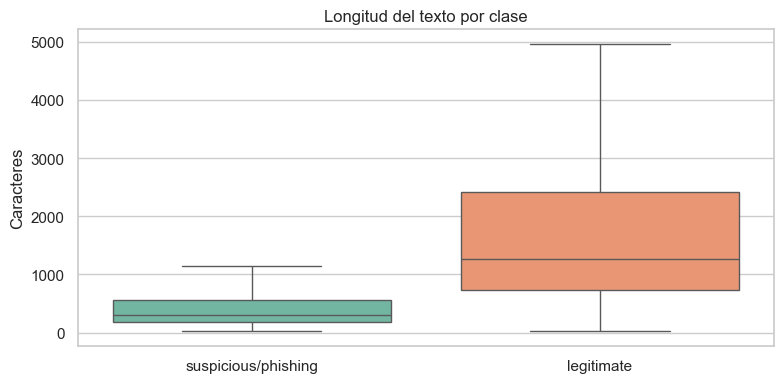

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=emails.assign(text_length=emails["email_text"].str.len()), x="label_name", y="text_length", showfliers=False, palette="Set2")
plt.title("Longitud del texto por clase")
plt.xlabel("")
plt.ylabel("Caracteres")
plt.tight_layout()

El resumen ya muestra por que el feedback era importante: hay senales en la URL, pero tambien hay diferencias claras en el contenido del correo. La longitud del texto, el vocabulario del asunto/cuerpo y la presencia o ausencia de enlaces forman parte del contexto que una URL por si sola no captura.

## 4. Separacion de datos

Uso tres particiones:

- **Train:** ajuste de los modelos.
- **Validation:** comparacion de modelos y refinamiento de umbral.
- **Test:** evaluacion final no usada durante el ajuste.

In [10]:
X = emails[["email_text"] + url_feature_cols].copy()
y = emails["label"].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, y_train.value_counts(normalize=True).round(3).to_dict())
print("Validation:", X_val.shape, y_val.value_counts(normalize=True).round(3).to_dict())
print("Test:", X_test.shape, y_test.value_counts(normalize=True).round(3).to_dict())

Train: (23377, 12) {1: 0.556, 0: 0.444}
Validation: (7793, 12) {1: 0.556, 0: 0.444}
Test: (7793, 12) {1: 0.556, 0: 0.444}


## 5. Implementacion de modelos

Se entrenan tres modelos logisticos para mantener interpretabilidad y comparabilidad:

1. **URL-only:** solo usa las caracteristicas numericas extraidas de URLs.
2. **Texto-only:** usa TF-IDF del asunto y cuerpo.
3. **Fusion URL + texto:** combina TF-IDF y caracteristicas de URL.

La regresion logistica es una buena linea base para este problema porque funciona bien con TF-IDF, entrega probabilidades y permite ajustar el umbral de decision.

In [11]:
text_preprocess = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=3,
    max_df=0.95,
    max_features=8000,
    ngram_range=(1, 2),
)

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

url_only_preprocessor = ColumnTransformer(
    transformers=[("url", numeric_preprocess, url_feature_cols)],
    remainder="drop",
)

text_only_preprocessor = ColumnTransformer(
    transformers=[("text", text_preprocess, "email_text")],
    remainder="drop",
)

fusion_preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_preprocess, "email_text"),
        ("url", numeric_preprocess, url_feature_cols),
    ],
    remainder="drop",
)

def make_model(preprocessor):
    return Pipeline(steps=[
        ("features", preprocessor),
        ("classifier", LogisticRegression(max_iter=1500, class_weight="balanced", solver="liblinear")),
    ])

models = {
    "URL-only": make_model(url_only_preprocessor),
    "Texto-only": make_model(text_only_preprocessor),
    "URL + texto": make_model(fusion_preprocessor),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Modelo entrenado: {name}")

Modelo entrenado: URL-only


Modelo entrenado: Texto-only


Modelo entrenado: URL + texto


In [12]:
def evaluate_model(model, X_eval, y_eval, threshold=0.5):
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, proba),
    }

val_metrics = pd.DataFrame({
    name: evaluate_model(model, X_val, y_val)
    for name, model in models.items()
}).T.sort_values("f1", ascending=False)

val_metrics.round(4)

,accuracy,precision,recall,f1,roc_auc
URL + texto,0.9937,0.9956,0.9931,0.9943,0.9995
Texto-only,0.9937,0.9961,0.9926,0.9943,0.9995
URL-only,0.7069,0.8057,0.6235,0.7030,0.7872


## 6. Refinamiento del modelo

El mejor modelo se selecciona en validacion por F1. Luego se ajusta el umbral de decision usando la curva Precision-Recall. En phishing, el umbral importa porque un falso negativo deja pasar una amenaza, mientras que demasiados falsos positivos pueden cansar al usuario o al analista.

In [13]:
best_model_name = val_metrics.index[0]
best_model = models[best_model_name]
val_proba = best_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

threshold_table = pd.DataFrame({
    "threshold": np.r_[thresholds, 1.0],
    "precision": precisions,
    "recall": recalls,
})
threshold_table["f1"] = 2 * (threshold_table["precision"] * threshold_table["recall"]) / (threshold_table["precision"] + threshold_table["recall"] + 1e-12)

best_threshold_row = threshold_table.sort_values("f1", ascending=False).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print("Mejor modelo en validacion:", best_model_name)
print("Umbral refinado por F1:", round(best_threshold, 4))
best_threshold_row.to_frame().T.round(4)

Mejor modelo en validacion: URL + texto
Umbral refinado por F1: 0.4325


,threshold,precision,recall,f1
3446,0.4325,0.994,0.9954,0.9947


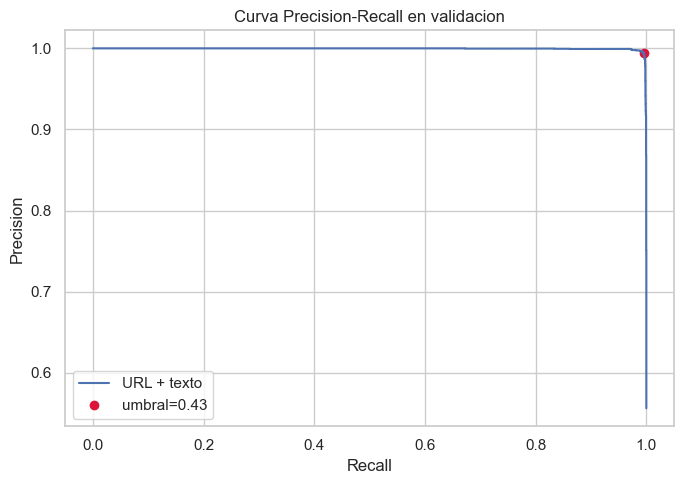

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label=best_model_name)
plt.scatter(best_threshold_row["recall"], best_threshold_row["precision"], color="crimson", label=f"umbral={best_threshold:.2f}")
plt.title("Curva Precision-Recall en validacion")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()

## 7. Evaluacion final en test

La evaluacion final se hace en el conjunto de test, que no se uso ni para entrenar ni para escoger el umbral. Se reportan Accuracy, Precision, Recall, F1 y ROC AUC para todas las alternativas.

In [15]:
test_metrics_default = pd.DataFrame({
    name: evaluate_model(model, X_test, y_test, threshold=0.5)
    for name, model in models.items()
}).T

test_metrics_tuned = test_metrics_default.copy()
test_metrics_tuned.loc[f"{best_model_name} refinado"] = evaluate_model(best_model, X_test, y_test, threshold=best_threshold)

test_metrics_tuned.sort_values("f1", ascending=False).round(4)

,accuracy,precision,recall,f1,roc_auc
Texto-only,0.9935,0.9945,0.9938,0.9941,0.9995
URL + texto,0.9932,0.9942,0.9935,0.9939,0.9991
URL + texto refinado,0.9909,0.9892,0.9945,0.9918,0.9991
URL-only,0.7067,0.7964,0.6351,0.7066,0.7875


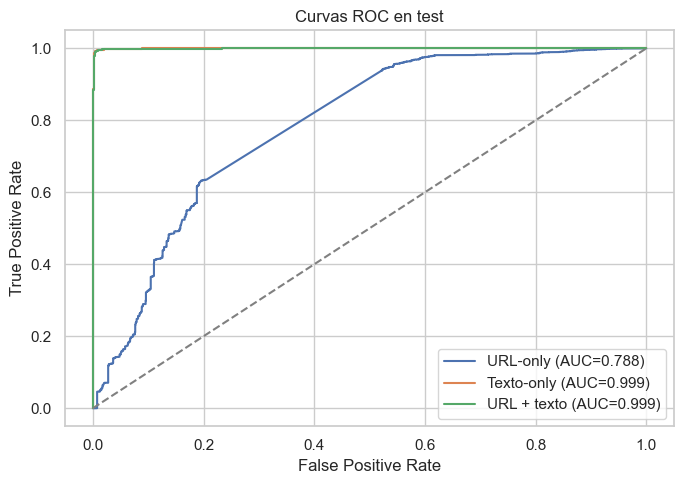

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Curvas ROC en test")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()

                     precision    recall  f1-score   support

         legitimate       0.99      0.99      0.99      3458
suspicious/phishing       0.99      0.99      0.99      4335

           accuracy                           0.99      7793
          macro avg       0.99      0.99      0.99      7793
       weighted avg       0.99      0.99      0.99      7793



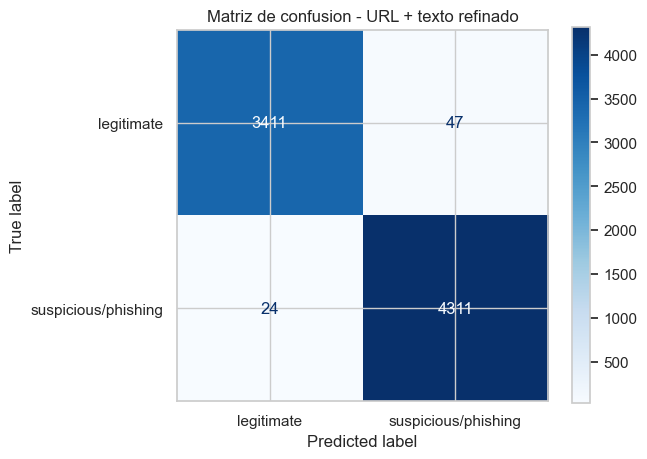

In [17]:
final_proba = best_model.predict_proba(X_test)[:, 1]
final_pred = (final_proba >= best_threshold).astype(int)

print(classification_report(y_test, final_pred, target_names=["legitimate", "suspicious/phishing"]))

cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["legitimate", "suspicious/phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusion - {best_model_name} refinado")
plt.tight_layout()

## 8. Interpretacion en el contexto del problema

El resultado mas importante no es solo el numero final, sino la comparacion entre alternativas:

- Si `URL-only` queda por debajo de `texto-only`, confirma que la URL aislada no captura todo el comportamiento del phishing.
- Si `URL + texto` supera o iguala al modelo textual, entonces las caracteristicas de URL agregan senales complementarias.
- Precision indica que tantos correos marcados como phishing realmente lo son; es importante para evitar demasiadas alertas falsas.
- Recall indica que tantos correos sospechosos se detectan; es critico porque un phishing no detectado puede terminar en robo de credenciales.
- F1 resume el balance entre precision y recall.
- ROC AUC mide la capacidad general del modelo para separar ambas clases sin depender de un unico umbral.

Para el proyecto, el modelo fusionado es el mas alineado con la propuesta investigada, porque combina el enlace con el texto social que acompana el ataque.

In [18]:
# Revision rapida de los terminos con mayor peso en el modelo textual/fusionado.
# Esto ayuda a explicar que senales textuales esta usando el clasificador.
if best_model_name in ["Texto-only", "URL + texto"]:
    clf = best_model.named_steps["classifier"]
    pre = best_model.named_steps["features"]
    feature_names = pre.get_feature_names_out()
    coefs = clf.coef_[0]
    weights = pd.DataFrame({"feature": feature_names, "weight": coefs})
    top_phishing = weights.sort_values("weight", ascending=False).head(15)
    top_legit = weights.sort_values("weight", ascending=True).head(15)
    display(top_phishing)
    display(top_legit)
else:
    print("El mejor modelo fue URL-only; revisar los coeficientes numericos.")

,feature,weight
1633,text__cnn,5.730491
3539,text__http,4.536938
1680,text__com,4.387314
3737,text__index html,4.262897
4398,text__love,4.131416
1637,text__cnn com,3.883039
4653,text__men,3.634302
4309,text__livefilestore com,3.315215
4308,text__livefilestore,3.315215
3375,text__health,3.309810


,feature,weight
7890,text__wrote,-6.422140
5179,text__org,-5.035330
5140,text__opensuse,-4.668122
5813,text__python,-4.003854
5377,text__perl,-3.815617
5886,text__rant,-3.665371
7124,text__thanks,-3.550488
289,text__2007,-3.461269
5590,text__postfix,-3.421571
7480,text__use,-2.959861


## 9. Conclusion

La Parte 1 sirvio para entender senales de URL, pero estaba incompleta para la propuesta original. En esta Parte 2 se corrige esa brecha al incorporar texto de correos y al evaluar modelos comparables. El enfoque final recomendado es el modelo `URL + texto`, porque representa mejor el escenario real: el usuario no recibe una URL en el vacio, sino un mensaje que intenta convencerlo de hacer clic.